# Step 1: Import Required Libraries

In [1]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Keras libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

# Evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 2: Load Dataset

In [2]:
# Load Fashion-MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist

# Split into training and testing data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Display shape of dataset
print("Training Images:", X_train.shape)
print("Testing Images:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


# Step 3: Data Preprocessing

In [3]:
# Normalize pixel values (0 to 1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape images for CNN input
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Convert output labels into categorical form
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Step 4: Build CNN Model

In [4]:
# Create CNN model
model = Sequential()

# First convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

# Second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# Fully connected layer
model.add(Dense(128, activation='relu'))

# Dropout layer
model.add(Dropout(0.3))

# Output layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 5: Compile Model

In [5]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Step 6: Train Model

In [6]:
# Train the CNN model
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8092 - loss: 0.5285 - val_accuracy: 0.8632 - val_loss: 0.3708
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8696 - loss: 0.3556 - val_accuracy: 0.8890 - val_loss: 0.3111
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8865 - loss: 0.3061 - val_accuracy: 0.8974 - val_loss: 0.2867
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8996 - loss: 0.2717 - val_accuracy: 0.9062 - val_loss: 0.2611
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9065 - loss: 0.2463 - val_accuracy: 0.9046 - val_loss: 0.2560
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9168 - loss: 0.2229 - val_accuracy: 0.9084 - val_loss: 0.2460
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9227 - loss: 0.2084 - val_accuracy: 0.9112 - val_loss: 0.2504
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9293 - loss: 0.1887 

# Step 7: Evaluate Model

In [7]:
# Evaluate on test data
loss, accuracy = model.evaluate(X_test, y_test_cat)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9113 - loss: 0.2649
Test Accuracy: 0.911300003528595
Test Loss: 0.26489487290382385


# Step 8: Classification Report

In [8]:
# Predict test labels
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Print report
print(classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      1000
           1       1.00      0.97      0.99      1000
           2       0.85      0.87      0.86      1000
           3       0.90      0.92      0.91      1000
           4       0.86      0.86      0.86      1000
           5       0.98      0.98      0.98      1000
           6       0.75      0.75      0.75      1000
           7       0.96      0.96      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.96      0.96      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



# Step 9: Confusion Matrix

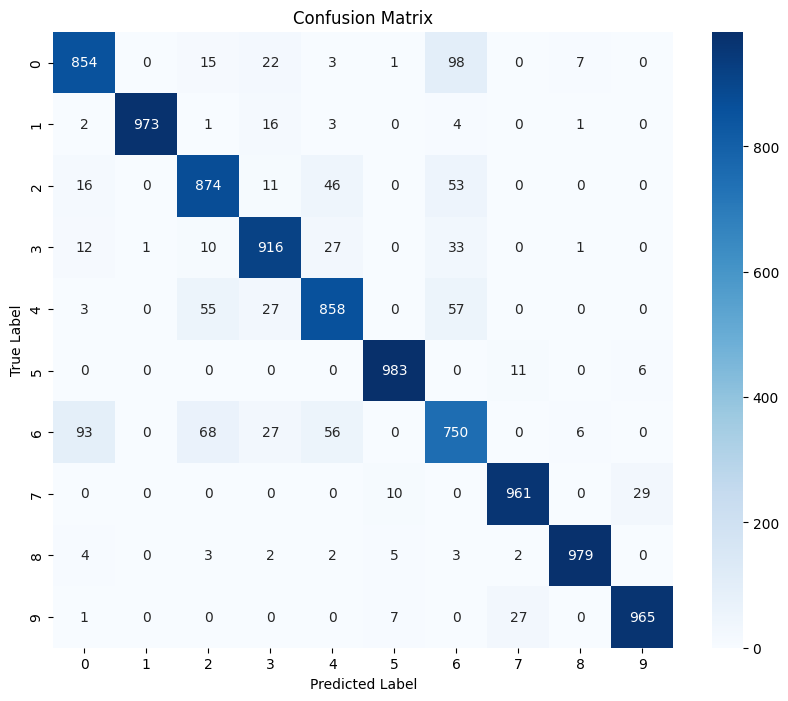

In [9]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# Step 10: Plot Accuracy and Loss Graphs

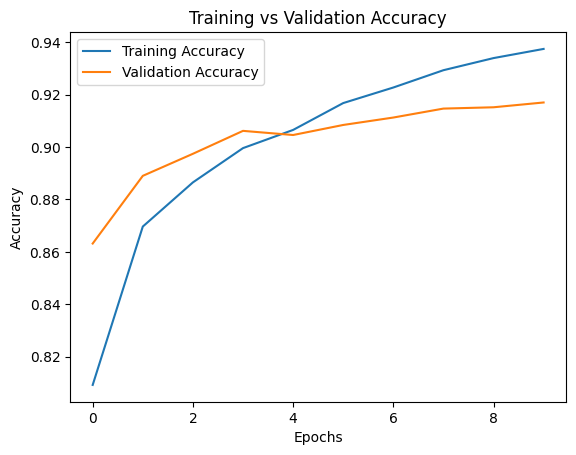

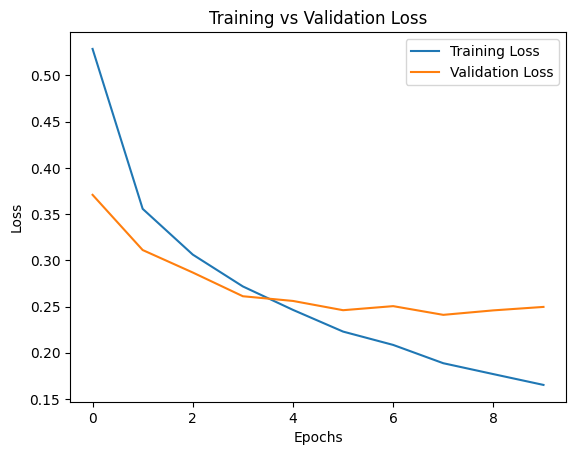

In [10]:
# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Step 11: Show Sample Predictions

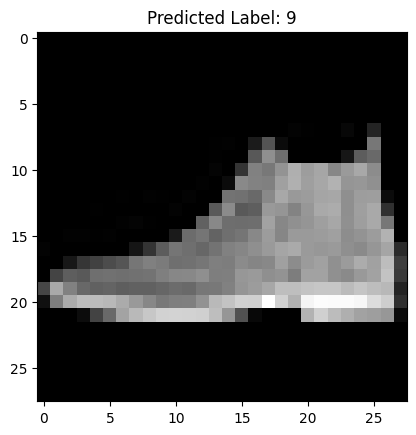

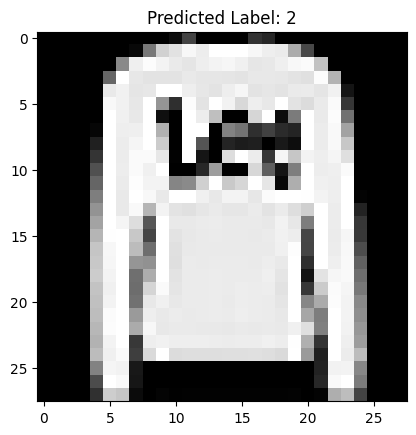

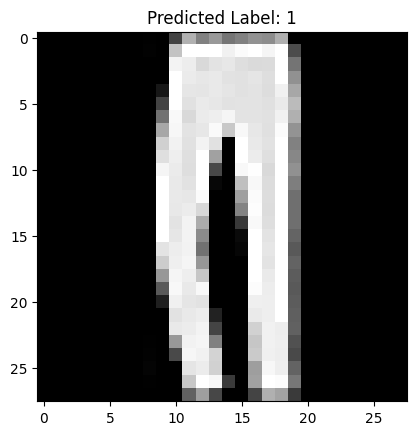

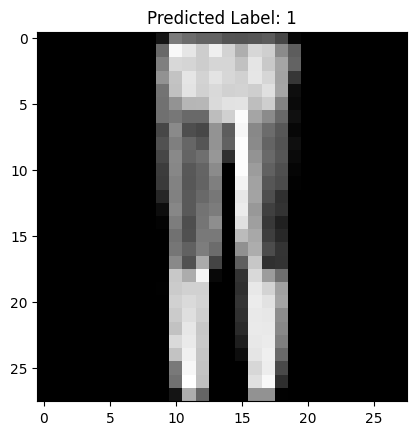

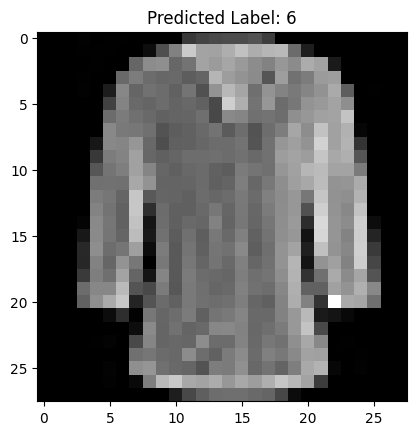

In [11]:
# Show first 5 predictions
for i in range(5):
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Predicted Label: " + str(y_pred_classes[i]))
    plt.show()